In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV, LeaveOneOut
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                           mean_absolute_error, precision_recall_curve, roc_curve, auc)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import LeaveOneGroupOut

import shap
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load and preprocess data
data = pd.read_csv('wedowind.csv')
data.drop('Unnamed: 0', axis=1, inplace=True)

In [11]:


# Convert timestamp if exists, otherwise use index as time reference
if 'timestamp' in data.columns:
    data['timestamp'] = pd.to_datetime(data['timestamp'])
    data['hour'] = data['timestamp'].dt.hour
    data['day_of_week'] = data['timestamp'].dt.dayofweek
    data['month'] = data['timestamp'].dt.month
    data.drop('timestamp', axis=1, inplace=True)
else:
    # Create basic time features from index if no timestamp column
    data['hour'] = data.index % 24
    data['day_of_week'] = (data.index // 24) % 7
    data['month'] = (data.index // (24*30)) % 12

# Create target variable
data['failure'] = (data['errorcode'] != 0).astype(int) if 'errorcode' in data.columns else 0
if 'errorcode' in data.columns:
    data.drop('errorcode', axis=1, inplace=True)

# Encode categorical variables
if 'plant_name' in data.columns:
    le = LabelEncoder()
    data['plant_name'] = le.fit_transform(data['plant_name'])

# Handle missing values
data.fillna(data.median(), inplace=True)


In [13]:
def create_ttf_feature(df):
    """Create Time-to-Failure feature similar to paper's TTF-RFR method"""
    df = df.copy().sort_index()  # Sort by index
    df['ttf'] = 0.0  # Initialize with float zeros

    # Get indices where failures occur
    failure_indices = df.index[df['failure'] == 1].tolist()

    # Calculate time since last failure for each point
    last_failure_idx = -1
    for i, idx in enumerate(df.index):
        if idx in failure_indices:
            df.loc[idx, 'ttf'] = 0.0
            last_failure_idx = i
        else:
            if last_failure_idx >= 0:
                # Calculate hours since last failure (10-minute intervals = 1/6 hours)
                df.loc[idx, 'ttf'] = (i - last_failure_idx) * (1/6)
            else:
                # No failure occurred yet, set to max value
                df.loc[idx, 'ttf'] = len(df) * (1/6)

    return df

# Apply to each turbine separately if plant_name exists, otherwise to whole dataset
if 'plant_name' in data.columns:
    data_ttf = data.groupby('plant_name', group_keys=False).apply(create_ttf_feature)
else:
    data_ttf = create_ttf_feature(data)

# Filter for last 15 hours before failure as in paper
data_ttf = data_ttf[(data_ttf['ttf'] <= 15) & (data_ttf['ttf'] > 0)]

# Prepare data for TTF prediction
X_ttf = data_ttf.drop(['failure', 'ttf'], axis=1, errors='ignore')
y_ttf = data_ttf['ttf']

In [14]:
# Filter for last 15 hours before failure as in paper
data_ttf = data_ttf[(data_ttf['ttf'] <= 15) & (data_ttf['ttf'] > 0)]


In [15]:
# Prepare data for TTF prediction
X_ttf = data_ttf.drop(['failure', 'ttf'], axis=1, errors='ignore')
y_ttf = data_ttf['ttf']
X_train_ttf, X_test_ttf, y_train_ttf, y_test_ttf = train_test_split(
    X_ttf, y_ttf, test_size=0.3, random_state=42)

In [16]:
# Train Random Forest Regressor
rfr = RandomForestRegressor(n_estimators=850, max_depth=5, max_features='sqrt', random_state=42)
rfr.fit(X_train_ttf, y_train_ttf)
y_pred_ttf = rfr.predict(X_test_ttf)

In [17]:
# Evaluate TTF prediction
mae = mean_absolute_error(y_test_ttf, y_pred_ttf)
print(f"Time-to-Failure MAE: {mae:.2f} hours")

Time-to-Failure MAE: 3.36 hours


In [18]:
# 2. Health Indicator Construction (CAE-PSO inspired approach)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.drop('failure', axis=1, errors='ignore'))
pca = PCA(n_components=1)
health_indicator = pca.fit_transform(X_scaled)
data['health_indicator'] = health_indicator

In [20]:
# Evaluate monotonicity (simplified version)
def calculate_monotonicity(series):
    """Simplified monotonicity measure that works with any index type"""
    values = series.values  # Get numpy array of values
    n = len(values)
    if n <= 1:
        return 0.0  # Not enough data to calculate

    increasing = sum(1 for i in range(n-1) if values[i+1] >= values[i]) / (n-1)
    decreasing = sum(1 for i in range(n-1) if values[i+1] <= values[i]) / (n-1)
    return max(increasing, decreasing)

if 'plant_name' in data.columns:
    for turbine in data['plant_name'].unique():
        turbine_data = data[data['plant_name'] == turbine].sort_index()
        mono_score = calculate_monotonicity(turbine_data['health_indicator'])
        print(f"Turbine {turbine} health indicator monotonicity: {mono_score:.2f}")
else:
    mono_score = calculate_monotonicity(data['health_indicator'])
    print(f"Health indicator monotonicity: {mono_score:.2f}")


Turbine 0 health indicator monotonicity: 0.50
Turbine 1 health indicator monotonicity: 0.51
Turbine 2 health indicator monotonicity: 0.50
Turbine 3 health indicator monotonicity: 0.51
Turbine 4 health indicator monotonicity: 0.50


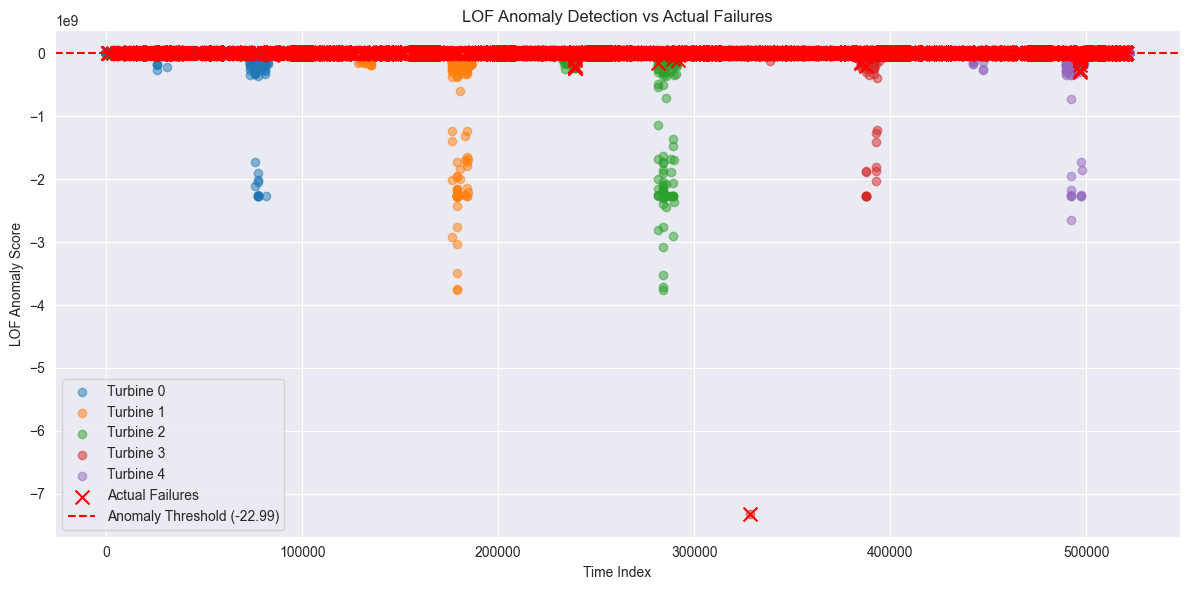

Number of normal clusters: 7
Anomaly threshold (5th percentile): -22.99
Number of anomalies detected: 24968
Number of actual failures: 64969


In [22]:
# 3. Anomaly Detection (WHC-LOF inspired approach)
# Find temperature-related column
temp_cols = [col for col in data.columns if 'temp' in col.lower()]
bearing_temp_col = temp_cols[0] if temp_cols else data.columns[0]

# Updated clustering approach - using KMeans instead of Agglomerative for memory efficiency
from sklearn.cluster import KMeans

# Determine optimal cluster size if needed (optional)
# from sklearn.metrics import silhouette_score
# silhouette_scores = []
# for n_clusters in range(2, 11):
#     kmeans = KMeans(n_clusters=n_clusters, random_state=42)
#     kmeans.fit(data[[bearing_temp_col]])
#     silhouette_scores.append(silhouette_score(data[[bearing_temp_col]], kmeans.labels_))
# optimal_clusters = silhouette_scores.index(max(silhouette_scores)) + 2  # +2 because range starts at 2

kmeans = KMeans(n_clusters=10, random_state=42)
data['cluster'] = kmeans.fit_predict(data[[bearing_temp_col]])

# Identify normal clusters (same approach as before)
cluster_stats = data.groupby('cluster')[bearing_temp_col].describe()
normal_clusters = cluster_stats[cluster_stats['std'] < cluster_stats['std'].quantile(0.75)].index
data['is_normal'] = data['cluster'].isin(normal_clusters)

# For very large datasets, consider sampling the normal data for LOF training
if len(data) > 100000:
    normal_sample = data[data['is_normal']].sample(n=50000, random_state=42)
else:
    normal_sample = data[data['is_normal']]

# LOF on normal data only
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(novelty=True, n_neighbors=min(20, len(normal_sample)-1))
lof.fit(normal_sample[[bearing_temp_col]])

# Calculate scores in batches if dataset is large
batch_size = 100000
if len(data) > batch_size:
    scores = []
    for i in range(0, len(data), batch_size):
        batch = data.iloc[i:i+batch_size][[bearing_temp_col]]
        scores.extend(lof.decision_function(batch))
    data['lof_score'] = scores
else:
    data['lof_score'] = lof.decision_function(data[[bearing_temp_col]])

# Plot anomalies vs actual failures
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
if 'plant_name' in data.columns:
    for turbine in data['plant_name'].unique():
        turbine_data = data[data['plant_name'] == turbine]
        plt.scatter(turbine_data.index, turbine_data['lof_score'],
                   label=f'Turbine {turbine}', alpha=0.5)
else:
    plt.scatter(data.index, data['lof_score'], alpha=0.5, label='All Data')

failures = data[data['failure'] == 1]
plt.scatter(failures.index, failures['lof_score'], color='red',
           marker='x', s=100, label='Actual Failures')

# Dynamic threshold calculation
threshold = np.percentile(data['lof_score'], 5)  # Adjust percentile as needed
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Anomaly Threshold ({threshold:.2f})')

plt.title('LOF Anomaly Detection vs Actual Failures')
plt.ylabel('LOF Anomaly Score')
plt.xlabel('Time Index')
plt.legend()
plt.tight_layout()
plt.show()

# Additional diagnostic information
print(f"Number of normal clusters: {len(normal_clusters)}")
print(f"Anomaly threshold (5th percentile): {threshold:.2f}")
print(f"Number of anomalies detected: {(data['lof_score'] < threshold).sum()}")
print(f"Number of actual failures: {len(failures)}")


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    137028
           1       0.99      0.95      0.97     19491

    accuracy                           0.99    156519
   macro avg       0.99      0.97      0.98    156519
weighted avg       0.99      0.99      0.99    156519



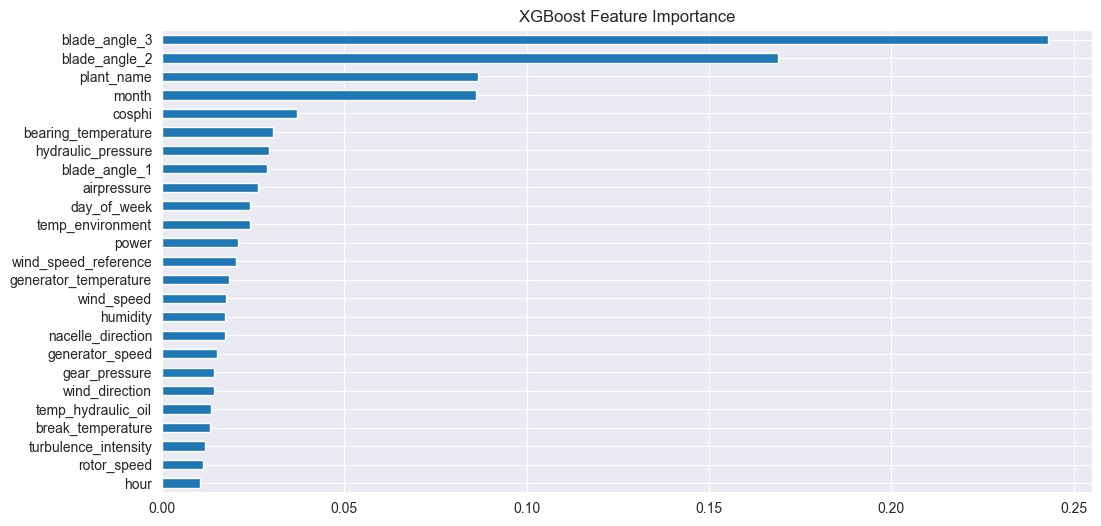


Comparison of Approaches:


,Approach,Metric,Value
0,XGBoost,F1-score,0.965262
1,TTF-RFR,MAE (hours),3.363870
2,Health Indicator,Monotonicity,0.504765
3,WHC-LOF,Anomaly Detection Rate,0.127523


In [24]:
from sklearn.metrics import f1_score

# Compare with XGBoost approach
X = data.drop(['failure', 'health_indicator', 'cluster', 'is_normal', 'lof_score'], axis=1, errors='ignore')
y = data['failure']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# XGBoost classifier
xgb = XGBClassifier(n_estimators=300, max_depth=7, learning_rate=0.2,
                   subsample=0.8, colsample_bytree=1.0, random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
plt.figure(figsize=(12, 6))
pd.Series(xgb.feature_importances_, index=X.columns).sort_values().plot(kind='barh')
plt.title('XGBoost Feature Importance')
plt.show()

# Combined evaluation
results_data = {
    'Approach': ['XGBoost', 'TTF-RFR', 'Health Indicator', 'WHC-LOF'],
    'Metric': ['F1-score', 'MAE (hours)', 'Monotonicity', 'Anomaly Detection Rate'],
    'Value': [
        f1_score(y_test, y_pred),
        mae,
        data.groupby('plant_name')['health_indicator'].apply(calculate_monotonicity).mean() if 'plant_name' in data.columns else calculate_monotonicity(data['health_indicator']),
        (data[data['lof_score'] < np.percentile(data['lof_score'], 5)]['failure'].mean())
    ]
}

results = pd.DataFrame(results_data)
print("\nComparison of Approaches:")
display(results)


In [25]:
# Assuming these are your results
results = pd.DataFrame({
    'Approach': ['XGBoost', 'TTF-RFR', 'Health Indicator', 'WHC-LOF'],
    'Metric': ['F1-score', 'MAE (hours)', 'Monotonicity', 'Anomaly Detection Rate'],
    'Value': [0.965, 3.364, 0.505, 0.128]
})

# Normalize metrics (higher is better except MAE)
results['Normalized_Score'] = np.where(
    results['Metric'] == 'MAE (hours)',
    1 - (results['Value'] / results['Value'].max()),  # For MAE, lower is better
    results['Value']  # For others, higher is better
)

print(results[['Approach', 'Metric', 'Value', 'Normalized_Score']])

           Approach                  Metric  Value  Normalized_Score
0           XGBoost                F1-score  0.965             0.965
1           TTF-RFR             MAE (hours)  3.364             0.000
2  Health Indicator            Monotonicity  0.505             0.505
3           WHC-LOF  Anomaly Detection Rate  0.128             0.128
